In [5]:
import sys
sys.path.append("..")

import torch
import matplotlib.pyplot as plt
from src.data.preprocessing import prepare_dataset
from src.inference.predict import load_models, predict

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [4]:
classifier_path = "../models/classification/weights/classifier_weighted_best.pt"
segmentation_path = "../models/segmentation/weights/unet_best.pt"

classifier, segmentation_model = load_models(classifier_path, segmentation_path, device)

In [6]:
DATA_DIR = "../data/raw/kaggle_3m"
df = prepare_dataset(DATA_DIR)

tumor_sample = df[df["has_tumor"] == True].iloc[50]
test_image_path = tumor_sample["image_path"]

result = predict(test_image_path, classifier, segmentation_model, device)

print(f"Has tumor: {result['has_tumor']}")
print(f"Confidence: {result['confidence']:.4f}")
print(f"Mask is None: {result['mask'] is None}")

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.0.1+cu118
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Has tumor: True
Confidence: 0.8923
Mask is None: False


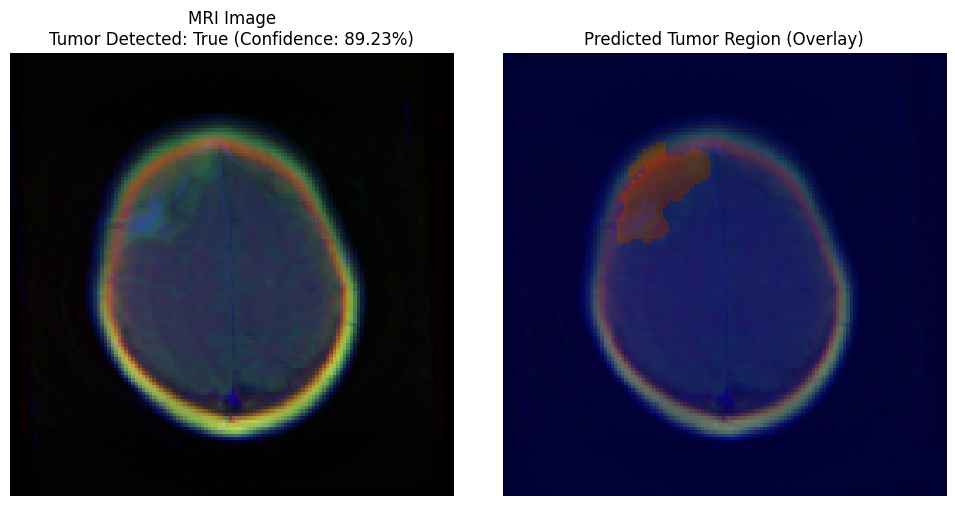

In [7]:
import cv2
import numpy as np

original_image = cv2.imread(test_image_path)
original_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)
original_image_resized = cv2.resize(original_image, (128, 128))

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(original_image_resized)
axes[0].set_title(f"MRI Image\nTumor Detected: {result['has_tumor']} (Confidence: {result['confidence']:.2%})")
axes[0].axis("off")

axes[1].imshow(original_image_resized)
axes[1].imshow(result["mask"], cmap="jet", alpha=0.4)
axes[1].set_title("Predicted Tumor Region (Overlay)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
no_tumor_sample = df[df["has_tumor"] == False].iloc[20]
test_image_path_2 = no_tumor_sample["image_path"]

result_2 = predict(test_image_path_2, classifier, segmentation_model, device)

print(f"Has tumor: {result_2['has_tumor']}")
print(f"Confidence: {result_2['confidence']:.4f}")
print(f"Mask is None: {result_2['mask'] is None}")

Has tumor: False
Confidence: 0.9754
Mask is None: True
